In [19]:
import pandas as pd
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("../Ontrac_data.csv")
df

,Invoice_Date,Client,Products,Amount,Bank_Document
0,9/2/2025,NOVAQUA,SIKACERAM 80I WHITE+GREY,21420.00,TRANSFER RECEIVED
1,9/8/2025,MY DE CONSTRUCTION,REBAR 08 TOR FE 500,11144.00,COLLECTION OF 1 BILL OF EXCHANGE
2,9/17/2025,TERRASTRUCT,CEMENT CPJ35 (21 T +19 bags),36790.00,TRANSFER RECEIVED
3,9/22/2025,STE DERRAB LISSAKAN,SIKACERAM 80I WHITE + GREY,4998.68,OFF-BRANCH CASH DEPOSIT
4,9/23/2025,STE DERRAB LISSAKAN,WOOD TALK LOUVERS 200X1200,4999.60,OFF-BRANCH CASH DEPOSIT
5,9/24/2025,NOVAQUA,CEMENT CPJ35 (29 T),43210.00,TRANSFER RECEIVED
6,9/24/2025,STE DERRAB LISSAKAN,SIKACERAM 80I WHITE + GREY,4999.68,OFF-BRANCH CASH DEPOSIT
7,9/25/2025,STE DERRAB LISSAKAN,SIKACERAM 80I WHITE + GREY,4999.68,OFF-BRANCH CASH DEPOSIT
8,9/26/2025,STE RACHIDIA CARREAUX,SIKACERAM 80I WHITE+GREY,44800.00,COLLECTION OF 1 LCN
9,9/26/2025,STE DERRAB LISSAKAN,SIKACERAM 80I WHITE + GREY,4999.68,OFF-BRANCH CASH DEPOSIT


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean text columns
df["Client"] = df["Client"].astype(str).str.strip()
df["Products"] = df["Products"].astype(str).str.strip()

# Optional: standardize product names
df["Products"] = (
    df["Products"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Check unique clients and products
print("Clients:")
print(f"Number of unique clients: {df['Client'].nunique()}")
print(df["Client"].unique())


print("\nProducts:")
print(f"Number of unique products: {df['Products'].nunique()}")
print(df["Products"].unique())


Clients:
Number of unique clients: 33
['NOVAQUA' 'MY DE CONSTRUCTION' 'TERRASTRUCT' 'STE DERRAB LISSAKAN'
 'STE RACHIDIA CARREAUX' 'ENT FAJER TAIBA' 'DAIMON IMMO'
 'STE ATLAS FINITION' 'AIT OUKHALI TRAVAUX' 'STE AF.ED'
 'STE OULAD ZAERS PROMO' 'MESTRACO' 'ELIPROMO' 'SCADACOM MAROC'
 'STE ARAFIK' 'NA MEGA S&C' 'MISCELLANEOUS (kamal hassan el amri)'
 'STE DELABIE BUIDING' 'MESWANE' 'EMTAC' 'TRAVAUX OMS' 'KRITAL'
 'STE SEMGIKA' 'FAHMI ABDELJALIL' 'DISTRAC' 'AHMED AZIZI' 'STE YOUSSDIV'
 'EMRAUDE PARK' 'STE ARAFIK (probable)' 'STE MY DE CONSTRUCTION'
 'FAHMI ABDELJALIL (CIN WA77205)' 'AYOUB MARRAKECH' 'ISMANE DEVELOPPEMENT']

Products:
Number of unique products: 57
['SIKACERAM 80I WHITE+GREY' 'REBAR 08 TOR FE 500'
 'CEMENT CPJ35 (21 T +19 bags)' 'SIKACERAM 80I WHITE + GREY'
 'WOOD TALK LOUVERS 200X1200' 'CEMENT CPJ35 (29 T)' 'SIKACERAM 80I GREY'
 'CEMENT CPJ35 (27 T)' 'CEMENT CPJ35 (28 T)' 'SIKACERAM 100M GREY'
 'SIKACERAM 100M GREY + WHITE' 'SIKACERAM 100M WHITE'
 'SIKACERAM 80I GREY + PRO

## 1.Which products are purchased by each client?

In [23]:
## one row per client-product

client_product_detail = (
    df[["Client", "Products"]]
    .drop_duplicates()
    .sort_values(["Client", "Products"])
)

client_product_detail

,Client,Products
92,AHMED AZIZI,WEBERCOL CLASSIC WHITE
43,AIT OUKHALI TRAVAUX,SIKACERAM + HAMRI ADHESIVE
48,AIT OUKHALI TRAVAUX,SIKACERAM + WEBER LATEX
119,AYOUB MARRAKECH,GURU WATERSTOP MAT (30 m2)
141,AYOUB MARRAKECH,HAMRI ADHESIVE GREY C1
123,AYOUB MARRAKECH,IMPERFLEX
130,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY
135,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY+DUR WHITE
124,AYOUB MARRAKECH,WEBERCOL CLASSIC WHITE
136,AYOUB MARRAKECH,WEBERCOL DUR WHITE


## 2.Which clients purchase the largest variety of products?

In [25]:
client_product_variety = (
    df.groupby("Client")["Products"]
      .nunique()
      .reset_index(name="Unique_Product_Count")
      .sort_values("Unique_Product_Count", ascending=False)
)

client_product_variety


,Client,Unique_Product_Count
21,STE ARAFIK,13
18,NOVAQUA,10
2,AYOUB MARRAKECH,8
25,STE DERRAB LISSAKAN,7
5,ELIPROMO,5
14,MESWANE,4
28,STE RACHIDIA CARREAUX,3
19,SCADACOM MAROC,3
4,DISTRAC,3
8,ENT FAJER TAIBA,2


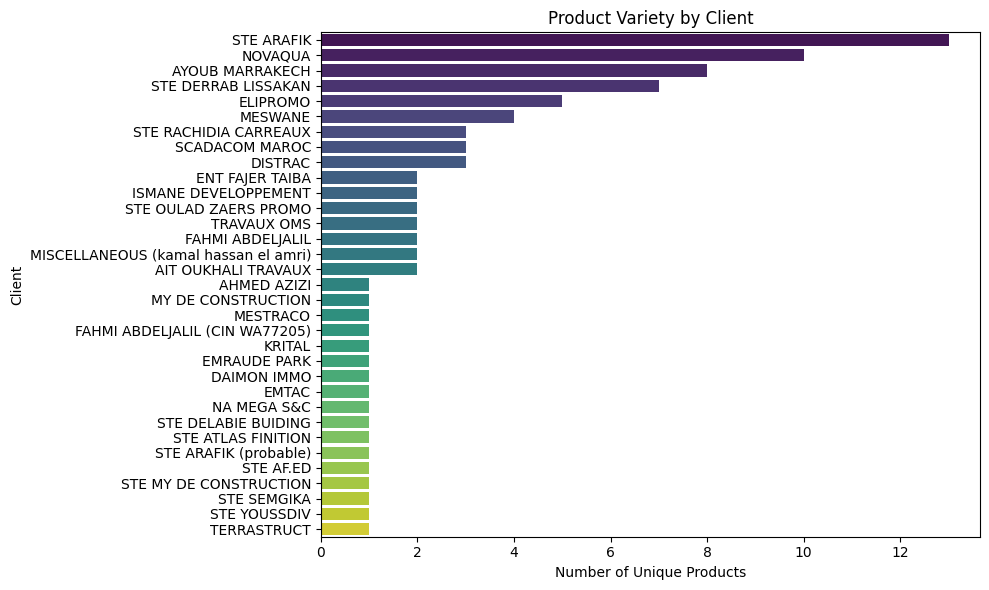

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=client_product_variety,
    x="Unique_Product_Count",
    y="Client",
    hue="Client",
    legend=False,
    palette="viridis"
)

plt.title("Product Variety by Client")
plt.xlabel("Number of Unique Products")
plt.ylabel("Client")

plt.tight_layout()
plt.show()


## 3.Which products are most frequently purchased by each client?

In [28]:
client_product_frequency = (
    df.groupby(["Client", "Products"])
      .size()
      .reset_index(name="Purchase_Count")
      .sort_values(
          ["Client", "Purchase_Count"],
          ascending=[True, False]
      )
)

client_product_frequency


,Client,Products,Purchase_Count
0,AHMED AZIZI,WEBERCOL CLASSIC WHITE,1
1,AIT OUKHALI TRAVAUX,SIKACERAM + HAMRI ADHESIVE,1
2,AIT OUKHALI TRAVAUX,SIKACERAM + WEBER LATEX,1
6,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY,7
8,AYOUB MARRAKECH,WEBERCOL CLASSIC WHITE,6
3,AYOUB MARRAKECH,GURU WATERSTOP MAT (30 m2),4
9,AYOUB MARRAKECH,WEBERCOL DUR WHITE,2
4,AYOUB MARRAKECH,HAMRI ADHESIVE GREY C1,1
5,AYOUB MARRAKECH,IMPERFLEX,1
7,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY+DUR WHITE,1


## 4.Are certain products strongly associated with particular clients?

In [38]:
client_product_count = (
    df.groupby(["Client", "Products"])
      .size()
      .reset_index(name="Purchase_Count")
)

client_product_count["Product_Total"] = (
    client_product_count
    .groupby("Products")["Purchase_Count"]
    .transform("sum")
)

client_product_count["Client_Share_of_Product_%"] = (
    client_product_count["Purchase_Count"]
    / client_product_count["Product_Total"]
    * 100
).round(2)

# Sort product count from maximum to lowest for each client
client_product_count = (
    client_product_count
    .sort_values(["Client", "Purchase_Count"], ascending=[True, False])
    .reset_index(drop=True)
)

client_product_count


,Client,Products,Purchase_Count,Product_Total,Client_Share_of_Product_%
0,AHMED AZIZI,WEBERCOL CLASSIC WHITE,1,16,6.25
1,AIT OUKHALI TRAVAUX,SIKACERAM + HAMRI ADHESIVE,1,1,100.00
2,AIT OUKHALI TRAVAUX,SIKACERAM + WEBER LATEX,1,1,100.00
3,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY,7,9,77.78
4,AYOUB MARRAKECH,WEBERCOL CLASSIC WHITE,6,16,37.50
5,AYOUB MARRAKECH,GURU WATERSTOP MAT (30 m2),4,4,100.00
6,AYOUB MARRAKECH,WEBERCOL DUR WHITE,2,2,100.00
7,AYOUB MARRAKECH,HAMRI ADHESIVE GREY C1,1,2,50.00
8,AYOUB MARRAKECH,IMPERFLEX,1,1,100.00
9,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY+DUR WHITE,1,1,100.00


## 6.Which clients are dependent on a single product?

In [39]:
client_product_dependency = (
    df.groupby("Client")
      .agg(
          Total_Purchases=("Products", "count"),
          Unique_Products=("Products", "nunique")
      )
      .reset_index()
)

client_product_dependency["Product_Concentration_%"] = (
    client_product_dependency["Unique_Products"]
    / client_product_dependency["Total_Purchases"]
    * 100
).round(2)

client_product_dependency


,Client,Total_Purchases,Unique_Products,Product_Concentration_%
0,AHMED AZIZI,1,1,100.00
1,AIT OUKHALI TRAVAUX,2,2,100.00
2,AYOUB MARRAKECH,23,8,34.78
3,DAIMON IMMO,1,1,100.00
4,DISTRAC,5,3,60.00
5,ELIPROMO,5,5,100.00
6,EMRAUDE PARK,1,1,100.00
7,EMTAC,1,1,100.00
8,ENT FAJER TAIBA,3,2,66.67
9,FAHMI ABDELJALIL,2,2,100.00


## 7.Which products have the broadest client base?

In [41]:
product_client_base = (
    df.groupby("Products")["Client"]
      .nunique()
      .reset_index(name="Unique_Client_Count")
      .sort_values("Unique_Client_Count", ascending=False)
)

product_client_base


,Products,Unique_Client_Count
49,WEBERCOL CLASSIC WHITE,6
33,SIKACERAM 100M+80I,5
12,CIMARPRO 35 (27 T),5
2,CEMENT CPJ35 (27 T),4
43,SIKACERAM 80I+HAMRI ADHESIVE,3
45,WEBERCOL CLASSIC GREY,3
3,CEMENT CPJ35 (27 T)+ PROLIDAL,2
11,CIMARPRO 35 (26 T),2
14,CIMARPRO 45 (27 T),2
51,WEBERCOL CLASSIC+JUNTA FINA,2


## 8. Which client-product combinations generate the most revenue?

In [46]:
client_product_revenue = (
    df.groupby(["Client", "Products"], as_index=False)["Amount"]
      .sum()
      .rename(columns={"Amount": "Total_Revenue"})
      .sort_values("Total_Revenue", ascending=False)
)

client_product_revenue


,Client,Products,Total_Revenue
39,NOVAQUA,CEMENT CPJ35 (27 T),201420.00
42,NOVAQUA,CEMENT CPJ35 (28 T),199230.00
49,SCADACOM MAROC,CIMARPRO 35 (27 T),162300.00
40,NOVAQUA,CEMENT CPJ35 (27 T)+ PROLIDAL,120690.00
43,NOVAQUA,CEMENT CPJ35 (29 T),86420.00
32,MESWANE,CIMARPRO 35 (27 T),82080.00
45,NOVAQUA,CIMARPRO 35 (27 T),81270.00
38,NA MEGA S&C,CIMARPRO 35 (27 T),80460.00
23,ENT FAJER TAIBA,SIKACERAM 80I GREY + PROLIDAL,54185.00
52,STE AF.ED,SIKACERAM 80I + HAMRI ADHESIVE,48500.00


In [48]:
client_product_summary = (
    df.groupby(["Client", "Products"])
      .agg(
          Purchase_Count=("Products", "size"),
          Total_Revenue=("Amount", "sum"),
          Average_Transaction=("Amount", "mean"),
          Min_Transaction=("Amount", "min"),
          Max_Transaction=("Amount", "max")
      )
      .reset_index()
      .sort_values("Total_Revenue", ascending=False)
)

client_product_summary = client_product_summary.round(2)

client_product_summary


,Client,Products,Purchase_Count,Total_Revenue,Average_Transaction,Min_Transaction,Max_Transaction
39,NOVAQUA,CEMENT CPJ35 (27 T),5,201420.00,40284.00,40230.00,40500.00
42,NOVAQUA,CEMENT CPJ35 (28 T),5,199230.00,39846.00,32350.00,41720.00
49,SCADACOM MAROC,CIMARPRO 35 (27 T),4,162300.00,40575.00,40230.00,41040.00
40,NOVAQUA,CEMENT CPJ35 (27 T)+ PROLIDAL,3,120690.00,40230.00,40230.00,40230.00
43,NOVAQUA,CEMENT CPJ35 (29 T),2,86420.00,43210.00,43210.00,43210.00
32,MESWANE,CIMARPRO 35 (27 T),2,82080.00,41040.00,41040.00,41040.00
45,NOVAQUA,CIMARPRO 35 (27 T),2,81270.00,40635.00,40230.00,41040.00
38,NA MEGA S&C,CIMARPRO 35 (27 T),2,80460.00,40230.00,40230.00,40230.00
23,ENT FAJER TAIBA,SIKACERAM 80I GREY + PROLIDAL,2,54185.00,27092.50,22560.00,31625.00
52,STE AF.ED,SIKACERAM 80I + HAMRI ADHESIVE,1,48500.00,48500.00,48500.00,48500.00
